In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


In [3]:
warnings.filterwarnings('ignore')


In [4]:
data = pd.read_csv('insurance.csv')

# top 3 rows and bottom 3 rows of the dataset
print(data.head(3))


   age     sex    bmi  children smoker     region     charges
0   19  female  27.90         0    yes  southwest  16884.9240
1   18    male  33.77         1     no  southeast   1725.5523
2   28    male  33.00         3     no  southeast   4449.4620


In [5]:
print(data.tail(3))
  

      age     sex    bmi  children smoker     region     charges
1335   18  female  36.85         0     no  southeast   1629.8335
1336   21  female  25.80         0     no  southwest   2007.9450
1337   61  female  29.07         0    yes  northwest  29141.3603


In [6]:

print(data.shape)   

(1338, 7)


In [7]:
#EDA 
print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [8]:
print(data.describe())



               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [9]:
# Check for missing values
print(data.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


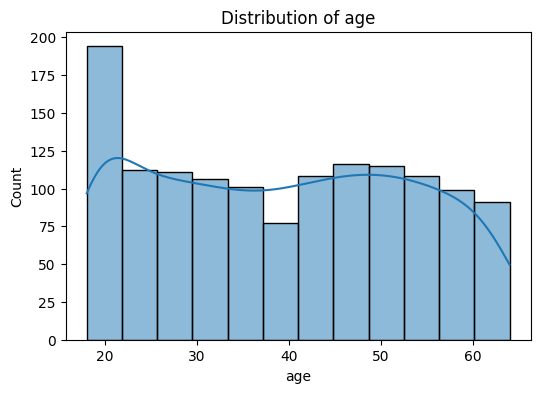

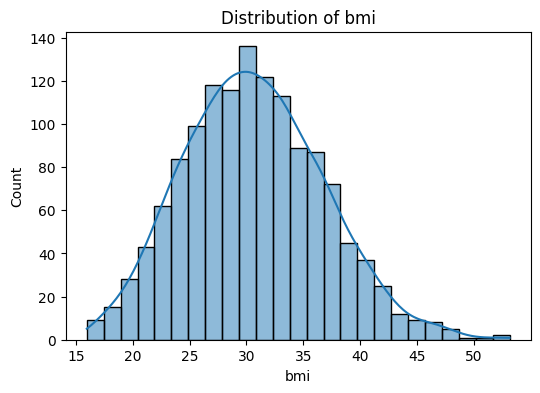

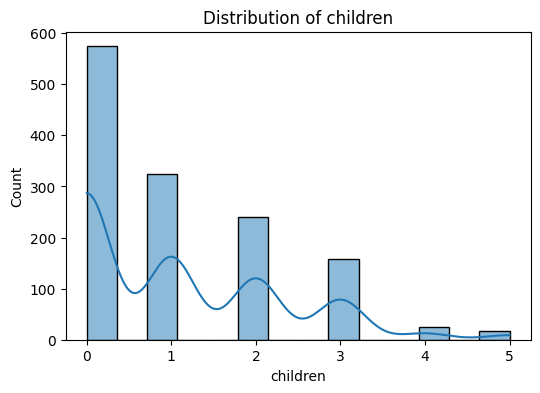

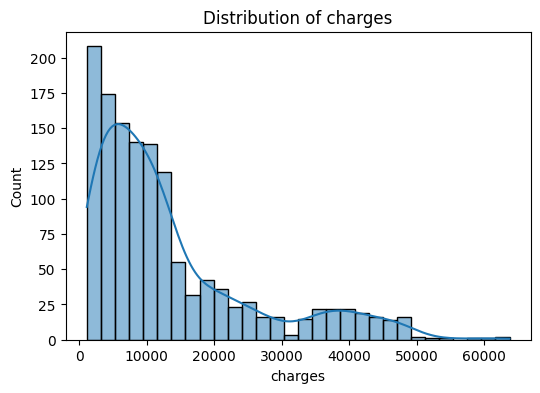

In [10]:
# # numeric colummnns 

numeric_col = ['age', 'bmi', 'children', 'charges']
for col in numeric_col:
    plt.figure(figsize=(6, 4))
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()  


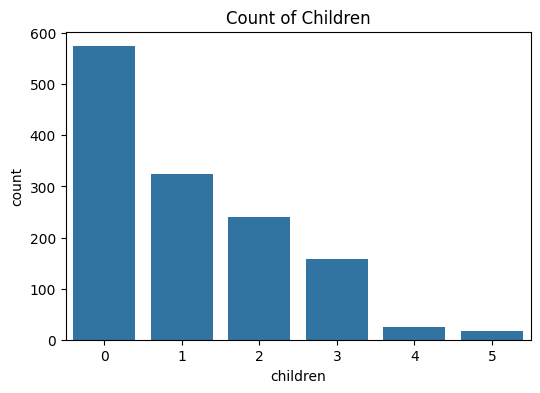

In [11]:
# countplot for children column

plt.figure(figsize=(6, 4))
sns.countplot(x='children', data=data)
plt.title('Count of Children')
plt.show()

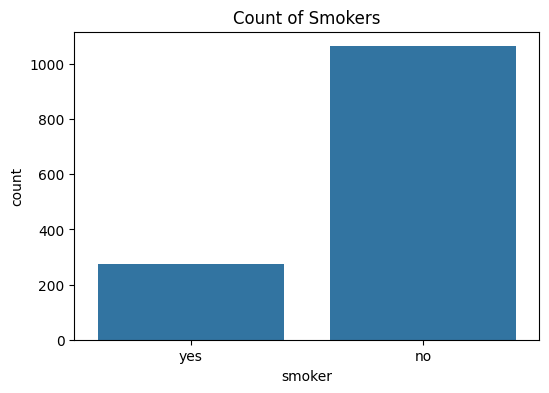

In [12]:
#countplot for smoker column

plt.figure(figsize=(6, 4))
sns.countplot(x='smoker', data=data)
plt.title('Count of Smokers')
plt.show()

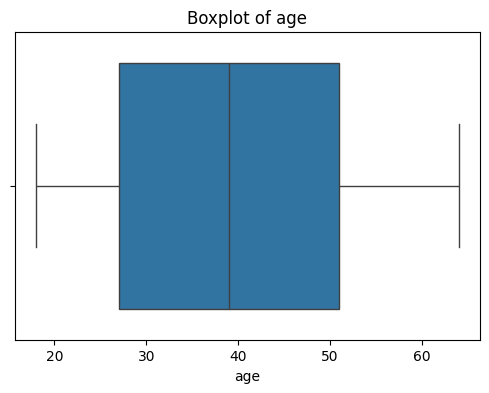

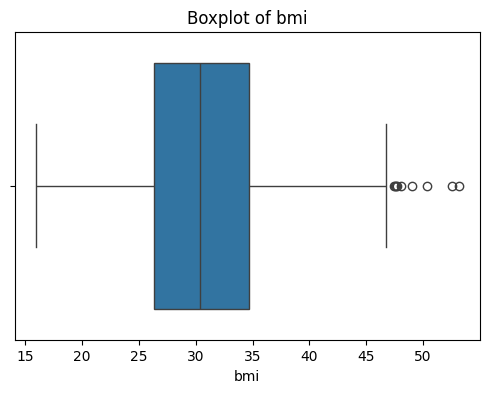

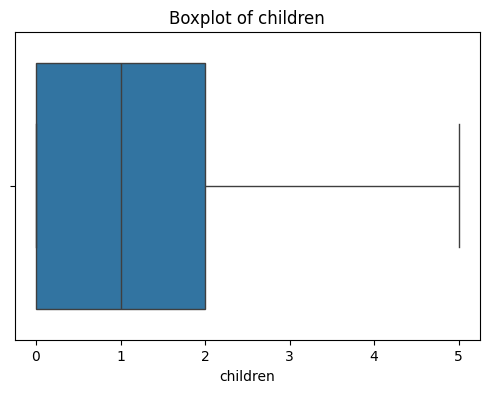

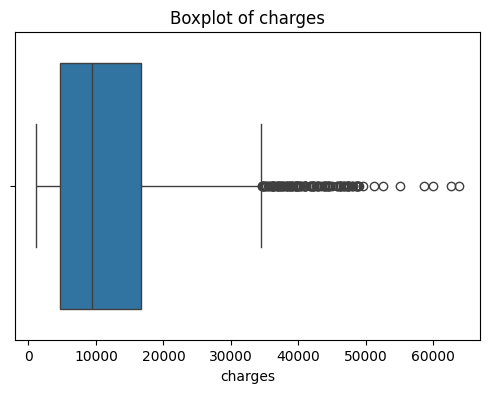

In [13]:
for col in numeric_col:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


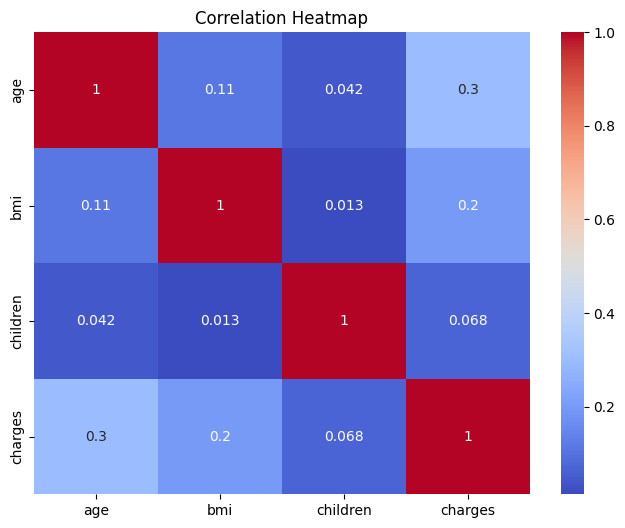

In [14]:
# correlation of the dataset
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(numeric_only=True) , annot=True, cmap='coolwarm')  # annot is used to display the correlation values on the heatmap
plt.title('Correlation Heatmap')
plt.show()

In [15]:
# Data cleaning and preprocessing

#copy of the dataset and analyze the cleaned dataset
df_cleaned = data.copy()
print(df_cleaned.head())


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [16]:
print(df_cleaned.drop_duplicates(inplace=True))


None


In [17]:

print(df_cleaned.shape)

(1337, 7)


In [18]:
print(df_cleaned['sex'].value_counts())


# smoker column encoding
df_cleaned['smoker'] = df_cleaned['smoker'].map({'yes': 1, 'no': 0})
print(df_cleaned['smoker'].value_counts())

sex
male      675
female    662
Name: count, dtype: int64
smoker
0    1063
1     274
Name: count, dtype: int64


In [19]:
#  sex column encoding
df_cleaned['sex'] = df_cleaned['sex'].map({'male': 1, 'female': 0})
print(df_cleaned['sex'].value_counts())


sex
1    675
0    662
Name: count, dtype: int64


In [20]:
# region column encoding
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], drop_first=True)
print(df_cleaned.head())


   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400             False   
1   18    1  33.770         1       0   1725.55230             False   
2   28    1  33.000         3       0   4449.46200             False   
3   33    1  22.705         0       0  21984.47061              True   
4   32    1  28.880         0       0   3866.85520              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [21]:
df_cleaned= df_cleaned.astype(int)
print(df_cleaned)

      age  sex  bmi  children  smoker  charges  region_northwest  \
0      19    0   27         0       1    16884                 0   
1      18    1   33         1       0     1725                 0   
2      28    1   33         3       0     4449                 0   
3      33    1   22         0       0    21984                 1   
4      32    1   28         0       0     3866                 1   
...   ...  ...  ...       ...     ...      ...               ...   
1333   50    1   30         3       0    10600                 1   
1334   18    0   31         0       0     2205                 0   
1335   18    0   36         0       0     1629                 0   
1336   21    0   25         0       0     2007                 0   
1337   61    0   29         0       1    29141                 1   

      region_southeast  region_southwest  
0                    0                 1  
1                    1                 0  
2                    1                 0  
3          

In [22]:
# Feature Engineering and Extraction

df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, np.inf], 
    labels=['Underweight', 'Normal weight', 'Overweight', 'Obese'])
print(df_cleaned.head())

   age  sex  bmi  children  smoker  charges  region_northwest  \
0   19    0   27         0       1    16884                 0   
1   18    1   33         1       0     1725                 0   
2   28    1   33         3       0     4449                 0   
3   33    1   22         0       0    21984                 1   
4   32    1   28         0       0     3866                 1   

   region_southeast  region_southwest   bmi_category  
0                 0                 1     Overweight  
1                 1                 0          Obese  
2                 1                 0          Obese  
3                 0                 0  Normal weight  
4                 0                 0     Overweight  


In [23]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_category'], drop_first=True)


In [24]:
print(df_cleaned.head())


   age  sex  bmi  children  smoker  charges  region_northwest  \
0   19    0   27         0       1    16884                 0   
1   18    1   33         1       0     1725                 0   
2   28    1   33         3       0     4449                 0   
3   33    1   22         0       0    21984                 1   
4   32    1   28         0       0     3866                 1   

   region_southeast  region_southwest  bmi_category_Normal weight  \
0                 0                 1                       False   
1                 1                 0                       False   
2                 1                 0                       False   
3                 0                 0                        True   
4                 0                 0                       False   

   bmi_category_Overweight  bmi_category_Obese  
0                     True               False  
1                    False                True  
2                    False                True 

In [25]:
print(df_cleaned.astype(int))

      age  sex  bmi  children  smoker  charges  region_northwest  \
0      19    0   27         0       1    16884                 0   
1      18    1   33         1       0     1725                 0   
2      28    1   33         3       0     4449                 0   
3      33    1   22         0       0    21984                 1   
4      32    1   28         0       0     3866                 1   
...   ...  ...  ...       ...     ...      ...               ...   
1333   50    1   30         3       0    10600                 1   
1334   18    0   31         0       0     2205                 0   
1335   18    0   36         0       0     1629                 0   
1336   21    0   25         0       0     2007                 0   
1337   61    0   29         0       1    29141                 1   

      region_southeast  region_southwest  bmi_category_Normal weight  \
0                    0                 1                           0   
1                    1                 

In [26]:
# colummns 
print(df_cleaned.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal weight', 'bmi_category_Overweight',
       'bmi_category_Obese'],
      dtype='object')


In [27]:

from sklearn.preprocessing import StandardScaler

cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])
print(df_cleaned.head(3))

        age  sex       bmi  children  smoker  charges  region_northwest  \
0 -1.440418    0 -0.517949 -0.909234       1    16884                 0   
1 -1.511647    1  0.462463 -0.079442       0     1725                 0   
2 -0.799350    1  0.462463  1.580143       0     4449                 0   

   region_southeast  region_southwest  bmi_category_Normal weight  \
0                 0                 1                       False   
1                 1                 0                       False   
2                 1                 0                       False   

   bmi_category_Overweight  bmi_category_Obese  
0                     True               False  
1                    False                True  
2                    False                True  


In [28]:
print(df_cleaned.astype(int))

      age  sex  bmi  children  smoker  charges  region_northwest  \
0      -1    0    0         0       1    16884                 0   
1      -1    1    0         0       0     1725                 0   
2       0    1    0         1       0     4449                 0   
3       0    1   -1         0       0    21984                 1   
4       0    1    0         0       0     3866                 1   
...   ...  ...  ...       ...     ...      ...               ...   
1333    0    1    0         1       0    10600                 1   
1334   -1    0    0         0       0     2205                 0   
1335   -1    0    0         0       0     1629                 0   
1336   -1    0    0         0       0     2007                 0   
1337    1    0    0         0       1    29141                 1   

      region_southeast  region_southwest  bmi_category_Normal weight  \
0                    0                 1                           0   
1                    1                 

In [29]:
from scipy.stats import pearsonr

selected_features   = ['age', 'bmi', 'children', 'smoker', 'sex', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_Normal weight', 'bmi_category_Overweight', 'bmi_category_Obese']
correlation = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}

correlations_df = pd.DataFrame(list(correlation.items()), columns=['Feature', 'Correlation with Charges'])
print(correlations_df)

                       Feature  Correlation with Charges
0                          age                  0.298309
1                          bmi                  0.196236
2                     children                  0.067390
3                       smoker                  0.787234
4                          sex                  0.058046
5             region_northwest                 -0.038695
6             region_southeast                  0.073577
7             region_southwest                 -0.043637
8   bmi_category_Normal weight                 -0.104042
9      bmi_category_Overweight                 -0.120601
10          bmi_category_Obese                  0.200348


In [30]:
cat_features = ['smoker', 'sex', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_Normal weight', 'bmi_category_Overweight', 'bmi_category_Obese']


In [31]:
from scipy.stats import chi2_contingency
alpha = 0.05
df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)


In [32]:
chi2_results = {}

In [33]:
for feature in cat_features:
    contingency_table = pd.crosstab(df_cleaned[feature], df_cleaned['charges_bin'])
    chi2, p,_,_ = chi2_contingency(contingency_table)
    decision = 'Reject Null (keep feature)' if p < alpha else 'Accept Null (drop feature)'
    chi2_results[feature] = {'Chi2 Statistic': chi2, 'p-value': p, 'Decision': decision}
chi2_results_df = pd.DataFrame.from_dict(chi2_results, orient='index').reset_index().rename(columns={'index': 'Feature'})
print(chi2_results_df)

                      Feature  Chi2 Statistic        p-value  \
0                      smoker      848.219178  1.507478e-183   
1                         sex       10.258784   1.648974e-02   
2            region_northwest        1.134240   7.688154e-01   
3            region_southeast       15.998167   1.134966e-03   
4            region_southwest        5.091893   1.651906e-01   
5  bmi_category_Normal weight        3.708088   2.947595e-01   
6     bmi_category_Overweight        4.251490   2.355571e-01   
7          bmi_category_Obese        8.515711   3.647336e-02   

                     Decision  
0  Reject Null (keep feature)  
1  Reject Null (keep feature)  
2  Accept Null (drop feature)  
3  Reject Null (keep feature)  
4  Accept Null (drop feature)  
5  Accept Null (drop feature)  
6  Accept Null (drop feature)  
7  Reject Null (keep feature)  


In [34]:
final_df = df_cleaned[['age', 'bmi', 'children', 'smoker', 'sex',  'region_southeast',  'bmi_category_Obese', 'charges']]
print(final_df.head(3))

        age       bmi  children  smoker  sex  region_southeast  \
0 -1.440418 -0.517949 -0.909234       1    0                 0   
1 -1.511647  0.462463 -0.079442       0    1                 1   
2 -0.799350  0.462463  1.580143       0    1                 1   

   bmi_category_Obese  charges  
0               False    16884  
1                True     1725  
2                True     4449  


In [35]:
print(final_df.astype(int))

      age  bmi  children  smoker  sex  region_southeast  bmi_category_Obese  \
0      -1    0         0       1    0                 0                   0   
1      -1    0         0       0    1                 1                   1   
2       0    0         1       0    1                 1                   1   
3       0   -1         0       0    1                 0                   0   
4       0    0         0       0    1                 0                   0   
...   ...  ...       ...     ...  ...               ...                 ...   
1333    0    0         1       0    1                 0                   1   
1334   -1    0         0       0    0                 0                   1   
1335   -1    0         0       0    0                 1                   1   
1336   -1    0         0       0    0                 0                   0   
1337    1    0         0       1    0                 0                   0   

      charges  
0       16884  
1        1725  
2  

In [36]:
from sklearn.model_selection import train_test_split   # importing the train_test_split function from the sklearn library


In [37]:
X = final_df.drop('charges', axis=1)
y = final_df['charges']

In [38]:
final_df.columns

Index(['age', 'bmi', 'children', 'smoker', 'sex', 'region_southeast',
       'bmi_category_Obese', 'charges'],
      dtype='object')

In [39]:
X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size=0.2, random_state=42)  

In [40]:
from sklearn.linear_model import LinearRegression

In [41]:

model = LinearRegression() # 
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [42]:
y_pred = model.predict(X_test)

In [43]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test , y_pred)
r2

n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
adjusted_r2


0.7987962362937232